## Characterization of the experimental groups

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# Constants
BARRELS_PER_TONNE = 7.33
TONNES_PER_MT = 1_000_000

In [2]:
MSCI_EM_constituent_list = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "United Arab Emirates"]

MSCI_EM_constituent_list_clean = [ "Brazil", "Chile", "China", "Colombia", "Czechia", "Egypt",
                             "Greece", "Hungary", "India", "Indonesia", "South Korea", "Kuwait", 
                             "Malaysia", "Mexico", "Peru", "Philippines", "Poland", "Qatar",
                            "Saudi Arabia", "South Africa", "Taiwan", "Thailand", "Turkey", "Abu Dhabi", "Dubai"] #Length: 24

### Valid CDS data

In [3]:
CDS_df = pd.read_csv('data/processed/CDS/Weekly_CDS.csv')
CDS_df['Date'] = pd.to_datetime(CDS_df['Date'])
CDS_df.set_index('Date', inplace=True)

CDS_df = CDS_df[CDS_df.index >= datetime.datetime(2014,1,1)].copy()
CDS_df = CDS_df[[col for col in CDS_df.columns if col in MSCI_EM_constituent_list_clean]]

cds_stats = []

for country in CDS_df.columns:
    # Get the time series for this country (drop NaN values)
    series = CDS_df[country].dropna()
    
    if len(series) > 0:
        # Start date
        start_date = series.index[0]
        
        # Calculate returns (percentage change from one row to next)
        returns = series.diff()
        
        # Count zero returns (where consecutive values are the same)
        zero_returns = (returns == 0).sum()
        
        # Percentage of zero returns
        total_returns = len(returns) - 1  # Exclude the first NaN from diff()
        pct_zero_returns = (zero_returns / total_returns * 100) if total_returns > 0 else 0
        
        cds_stats.append({
            'Country': country,
            'Series Start': start_date,
            'Observations': len(series),
            'Zero Returns (%)': round(pct_zero_returns, 2),
            'Decision': "Keep" if pct_zero_returns < 5 else "Discard"
        })

# Create and display the statistics table
cds_stats_df = pd.DataFrame(cds_stats).sort_values('Country')
print(cds_stats_df.to_string(index=False))
print(f"\nTotal countries: {len(cds_stats_df)}")



     Country Series Start  Observations  Zero Returns (%) Decision
   Abu Dhabi   2014-01-03           574              1.92     Keep
      Brazil   2014-01-03           574              0.35     Keep
       Chile   2014-01-03           574              0.52     Keep
       China   2014-01-03           574              1.57     Keep
    Colombia   2014-01-03           574              0.00     Keep
     Czechia   2014-01-03           574             16.58  Discard
       Dubai   2014-01-03           574              6.46  Discard
       Egypt   2014-01-03           574              1.40     Keep
      Greece   2014-01-03           574             25.13  Discard
     Hungary   2014-01-03           574              4.36     Keep
       India   2015-03-27           510             41.65  Discard
   Indonesia   2014-01-03           574              0.87     Keep
      Kuwait   2017-06-16           394             32.32  Discard
    Malaysia   2014-01-03           574              1.57     

In [4]:
# Crude oil balance (need to handle apostrophe thousands separator)
crude_oil_balance = pd.read_csv('data/processed/Oil/crude_oil_trade_balance.csv', 
                                 thousands="'")
crude_oil_balance.set_index('Country', inplace=True)

crude_filtered = crude_oil_balance.loc[crude_oil_balance.index.isin(MSCI_EM_constituent_list)]

crude_filtered = crude_filtered.T
crude_filtered.index = crude_filtered.index.astype(int)

# Oil prices
annual_oil_price = pd.read_csv('data/processed/Oil/Annual_avg_price_of_oil_macrotrends.csv')
annual_oil_price['Year'] = pd.to_datetime(annual_oil_price['Date']).dt.year
oil_prices = annual_oil_price.set_index('Year')['Value']

# GDP (long format)
gdp_wide = pd.read_csv('data/processed/Macroeconomic_variables/annual_GDP_IMFWEO.csv')


In [5]:
# -----------------------------------------------------------------------------
# CONVERT MT TO USD BILLIONS
# -----------------------------------------------------------------------------

# After loading and filtering crude oil balance, convert to numeric
crude_filtered = crude_filtered.apply(pd.to_numeric, errors='coerce')

crude_oil_usd = crude_filtered.copy()
# Then do the conversion
for year in crude_oil_usd.index:
    if year in oil_prices.index:
        price = oil_prices[year]
        crude_oil_usd.loc[year] = crude_filtered.loc[year] * TONNES_PER_MT * BARRELS_PER_TONNE * price / 1e9

gdp_wide

,COUNTRY,FREQUENCY,SCALE,2000,2001,2002,2003,2004,2005,2006,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Advanced Economies,Annual,Billions,26960.202,26687.422,27845.422,31241.269,34664.257,36491.101,38380.458,...,45711.404,46951.019,49016.624,51868.982,52406.467,51561.468,57609.524,58945.923,62310.258,64901.125
1,United Kingdom,Annual,Billions,1668.690,1650.252,1788.549,2056.294,2422.619,2546.038,2712.257,...,2928.558,2699.086,2682.384,2875.024,2853.074,2698.705,3144.079,3125.404,3371.118,3644.636
2,G7,Annual,Billions,22112.210,21854.685,22533.722,24879.158,27331.248,28544.573,29771.997,...,34938.790,35927.787,37196.592,39238.227,39958.027,39273.741,43438.469,44740.682,47490.417,49422.823
3,United States,Annual,Billions,10250.950,10581.925,10929.100,11456.450,12217.175,13039.200,13815.600,...,18295.000,18804.900,19612.100,20656.525,21539.975,21375.275,23725.650,26054.600,27811.500,29298.025
4,Germany,Annual,Billions,1967.850,1966.395,2100.865,2534.081,2851.023,2894.992,3046.470,...,3425.446,3535.812,3764.023,4057.272,3960.332,3938.244,4358.147,4204.327,4563.523,4684.182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,North Macedonia,Annual,Billions,3.774,3.709,3.991,4.946,5.684,6.257,6.860,...,10.067,10.686,11.336,12.694,12.609,12.385,14.008,13.957,15.772,16.679
206,World,Annual,Billions,34263.497,34017.996,35100.176,39415.473,44373.630,48097.282,52123.661,...,75830.968,77051.495,81951.771,87038.871,88323.317,86051.313,98225.820,102401.753,106939.787,111112.860
207,Kosovo,Annual,Billions,2.217,2.509,2.730,3.390,3.710,3.828,4.019,...,6.296,6.681,7.178,7.882,7.900,7.728,9.418,9.375,10.470,11.200
208,Romania,Annual,Billions,37.447,40.396,46.035,57.790,75.059,98.547,122.114,...,177.878,185.337,210.530,243.651,251.652,252.372,286.783,296.928,350.847,382.854


In [11]:
# -----------------------------------------------------------------------------
# PREPARE GDP (map country names and convert to billions)
# -----------------------------------------------------------------------------

#Filter selected columns
gdp_filtered = gdp_wide.drop(columns=['FREQUENCY','SCALE'])

#Set index
gdp_filtered.set_index('COUNTRY',inplace=True)

# Filter to selected countries
gdp_filtered = gdp_filtered.loc[gdp_filtered.index.isin(MSCI_EM_constituent_list)]

# Transpose: index = years, columns = countries
gdp_transposed = gdp_filtered.T
gdp_transposed.index = gdp_transposed.index.astype(int)

#gdp_transposed
gdp_transposed

COUNTRY,Greece,Turkey,South Africa,Colombia,Brazil,Chile,Mexico,Peru,Kuwait,Qatar,...,Taiwan,Malaysia,South Korea,India,Philippines,Thailand,China,Czechia,Hungary,Poland
2000,127.438,273.570,151.855,99.270,655.454,78.250,742.061,50.414,37.714,18.085,...,330.680,102.149,597.802,468.396,83.667,126.392,1220.337,62.171,47.276,172.151
2001,132.051,203.001,135.527,97.606,559.982,71.517,796.055,51.034,34.906,17.498,...,299.276,101.054,567.655,485.440,78.921,120.296,1351.372,68.136,53.800,191.403
2002,150.148,238.674,129.385,97.353,509.798,70.295,810.666,53.954,38.129,19.334,...,307.439,109.833,649.747,514.938,84.307,134.301,1486.618,82.596,67.636,199.694
2003,196.881,317.342,197.017,94.072,558.232,76.508,765.550,58.537,47.869,23.716,...,317.381,120.025,728.497,607.701,87.039,152.281,1680.942,100.471,85.190,218.561
2004,234.873,408.309,256.188,116.382,669.290,99.079,819.459,66.126,59.439,30.651,...,346.924,135.869,822.583,709.152,95.002,172.896,1978.937,120.148,104.015,256.454
2005,242.450,506.794,288.749,145.601,891.633,122.315,917.572,74.232,80.799,44.636,...,374.060,150.345,971.540,820.385,107.420,189.318,2325.515,137.264,113.098,307.158
2006,269.088,554.902,304.055,161.793,1107.628,153.840,1020.265,87.459,101.548,58.629,...,386.450,170.410,1094.545,940.260,127.653,221.758,2797.286,156.236,115.604,345.898
2007,314.264,686.909,332.650,206.230,1397.114,172.565,1102.356,102.187,114.608,75.987,...,406.907,202.732,1220.756,1216.736,155.980,262.943,3612.210,189.845,140.123,429.715
2008,351.083,787.897,316.491,242.504,1695.855,179.663,1161.553,120.898,147.391,112.621,...,415.901,241.946,1093.487,1198.895,181.007,291.383,4653.314,236.820,158.228,535.612
2009,326.474,656.134,331.184,232.469,1669.204,171.794,943.437,122.214,105.992,88.196,...,390.829,211.847,982.854,1341.889,176.132,281.711,5176.180,207.095,130.807,440.954


In [15]:
# -----------------------------------------------------------------------------
# CALCULATE OIL BALANCE AS % OF GDP
# -----------------------------------------------------------------------------

common_years = crude_oil_usd.index.intersection(gdp_transposed.index)
common_countries = crude_oil_usd.columns.intersection(gdp_transposed.columns)

print(f"\nCommon years: {common_years.min()} - {common_years.max()}")
print(f"Common countries: {list(common_countries)}")

crude_aligned = crude_oil_usd.loc[common_years, common_countries]
gdp_aligned = gdp_transposed.loc[common_years, common_countries]

oil_balance_pct_gdp = (crude_aligned / gdp_aligned) * 100


# -----------------------------------------------------------------------------
# SUMMARY TABLE
# -----------------------------------------------------------------------------
start_year = 2014
end_year = 2024

recent_years = [y for y in range(start_year, end_year + 1) if y in oil_balance_pct_gdp.index]
avg_balance = oil_balance_pct_gdp.loc[recent_years].mean().sort_values(ascending=True)  # ascending so exporters (negative) at top

print("\n" + "="*60)
print(f"AVERAGE CRUDE OIL TRADE BALANCE (% of GDP), {start_year}-{end_year}")
print("="*60)

for country in avg_balance.index:
    print(f"{country:20s}: {avg_balance[country]:+.2f}%")



Common years: 2000 - 2024
Common countries: ['Czechia', 'Poland', 'Turkey', 'Brazil', 'Chile', 'Colombia', 'Mexico', 'China', 'India', 'Indonesia', 'Malaysia', 'Philippines', 'South Korea', 'Taiwan', 'Thailand', 'Egypt', 'South Africa', 'Kuwait', 'Qatar', 'Saudi Arabia', 'United Arab Emirates']

AVERAGE CRUDE OIL TRADE BALANCE (% of GDP), 2014-2024
Kuwait              : -30.93%
Saudi Arabia        : -18.03%
United Arab Emirates: -12.33%
Qatar               : -11.23%
Colombia            : -4.06%
Mexico              : -1.95%
Brazil              : -1.17%
Egypt               : -0.53%
Malaysia            : -0.46%
Indonesia           : +0.32%
Philippines         : +0.98%
Czechia             : +1.31%
Turkey              : +1.40%
Chile               : +1.44%
China               : +1.46%
South Africa        : +1.76%
Poland              : +1.95%
Taiwan              : +3.52%
India               : +3.70%
South Korea         : +3.79%
Thailand            : +4.48%


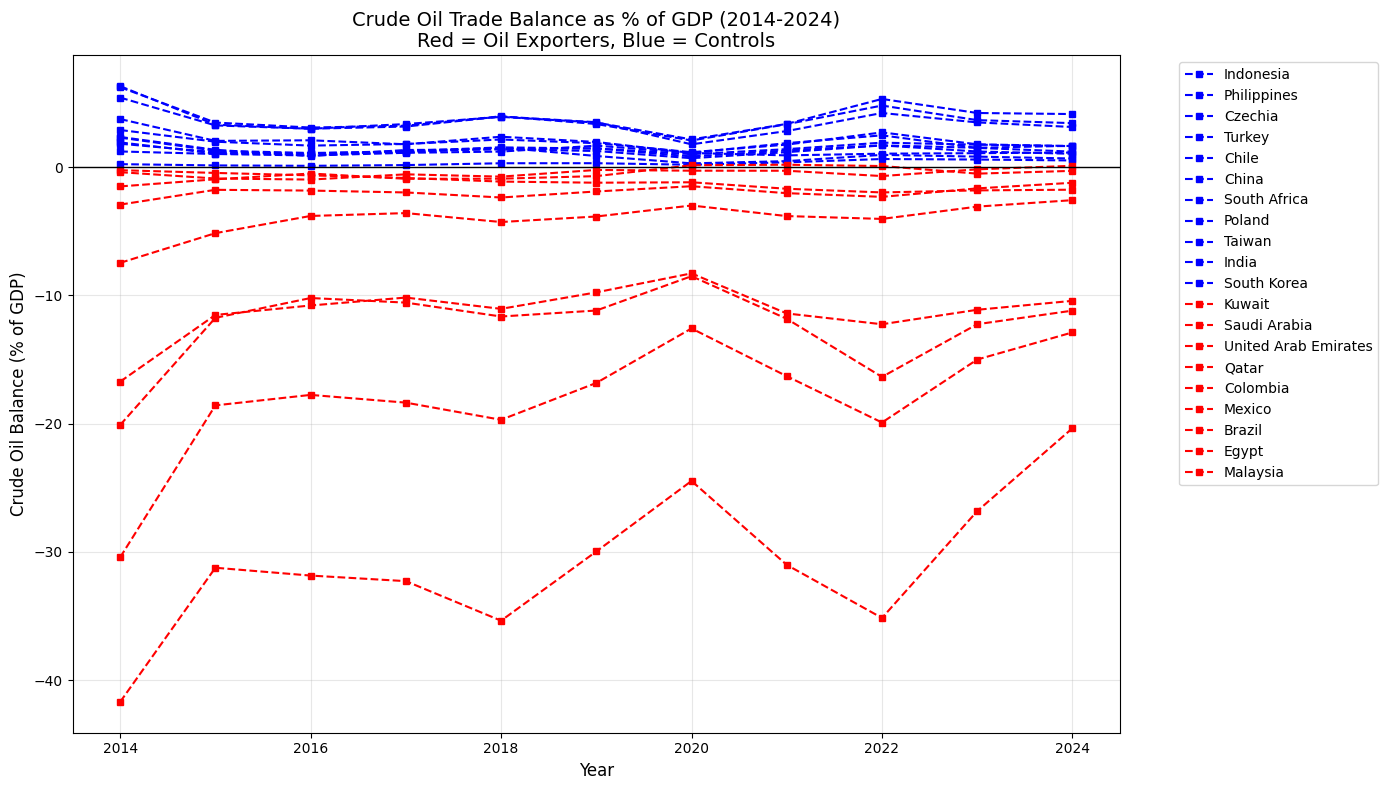

In [17]:
# -----------------------------------------------------------------------------
# PLOT
# -----------------------------------------------------------------------------

oil_exporters = ['Kuwait','Saudi Arabia', 'United Arab Emirates','Qatar','Colombia','Mexico','Brazil','Egypt','Malaysia']
controls = ['Indonesia','Philippines','Czechia','Turkey','Chile','China','South Africa',
            'Poland','Taiwan','India','South Korea','Tailand']

oil_balance_plot = oil_balance_pct_gdp.loc[start_year:end_year]

fig, ax = plt.subplots(figsize=(14, 8))

for country in controls:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                's--', color='blue', linewidth=1.5, markersize=4, label=country)
        
for country in oil_exporters:
    if country in oil_balance_plot.columns:
        ax.plot(oil_balance_plot.index, oil_balance_plot[country], 
                's--', color='red', linewidth=1.5, markersize=4, label=country)

ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Crude Oil Balance (% of GDP)', fontsize=12)
ax.set_title(f'Crude Oil Trade Balance as % of GDP ({start_year}-{end_year})\nRed = Oil Exporters, Blue = Controls', fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Proposed groups

In [ ]:
oil_exporters = ['Saudi Arabia', 'United Arab Emirates','Qatar','Colombia','Mexico','Brazil','Egypt','Malaysia']
controls = ['Indonesia','Philippines','Turkey','Chile','China','South Africa','South Korea','Tailand'] 